# **Google Certificate Capstone Case Study 1: How does a bike-share navigate speedy success?**

### The Senario of the Case Study 1 is listed as below:
You are a junior data analyst working on the marketing analyst team at Cyclistic, a bike-share
company in Chicago. The director of marketing believes the company’s future success
depends on maximizing the number of annual memberships. Therefore, your team wants to
understand how casual riders and annual members use Cyclistic bikes differently. From these
insights, your team will design a new marketing strategy to convert casual riders into annual
members. But first, Cyclistic executives must approve your recommendations, so they must be
backed up with compelling data insights and professional data visualizations.

### The Characters and Teams of this Senario:
* **Cyclistic**: A bike Share Program that featrues more than 5800 bicycles and 600 docking stations.
* **Lily Moreno**: The Director of marketing and your manager.
* **Cyclisitc marketing analytics team**: They are responsible for collecting, analyzing, and reporting data that helps guide Cyclisitc marketing strategy.
* **Cyclistic executive team**: The notoriously detail-oriented executive team will decide whether to approve the recommended marketing program.

### DataSet:
* **The name of Data**: Cyclistic Trip Data (Divvy Bikes)
* **Source**: https://divvy-tripdata.s3.amazonaws.com/index.html
* **Period**: Most recent 12 months of 2025 data
* **Format**: The Data are monthly in CSV files

# 1. ASK - Define the Buisness Problem:
**Buisness Task**
Design marketing strategies to converte casual riders into
annual members by analyzing the Cyclisitc historical bike trip data to identify trends.
**Key Stakeholder**
* Lily Moreno
* Cyclistic markting analytics team
* Cyclistic executive team

**The Guide Question that this analysis will cover**
> How do annual members and casual riders use Cyclistic bikes differently?

# 2. PREPARE - Upload the Data and Understand it 

#### This Data doesn't contain Personally Identifable Information like credit card numbers.I am only analysis the trends rather than individuals.

#### **Import the Library that I will Use in the Analysis and the Data**

In [1]:
# Import the Libraries
import pandas as pd
import glob
import os
import matplotlib as mtpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy

# 1. Define the path of the folder that store the 12 CSVs
path = '/kaggle/input/datasets/ahmedmashal/cyclistics-bike-share-2023'
# 2. Get a list of the Data of the file
all_files = glob.glob(os.path.join(path,'*.csv'))
# 3. Define a list that store the Data in it
data_frames = []
# 4. Store the Data in a list of array in the Data frames
for filename in all_files:
    df = pd.read_csv(filename)
    data_frames.append(df)
# 5. Concatunate all data to be in one data frame
trip_data_2025 = pd.concat(data_frames,ignore_index=True)
# 6. Check the result
print(f"total rows data: {len(trip_data_2025)}")
trip_data_2025.head()

total rows data: 5552994


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,BADF67E2C5058F19,classic_bike,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,DuSable Lake Shore Dr & North Blvd,LF-005,Winthrop Ave & Lawrence Ave,TA1308000021,41.911722,-87.626804,41.968812,-87.657659,member
1,0210AE485D59C8C5,electric_bike,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,Damen Ave & Grand Ave,TA1308000006,Desplaines St & Jackson Blvd,15539,41.892394,-87.676885,41.878119,-87.643948,member
2,5E68FE5B9283E4C4,classic_bike,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,LaSalle St & Illinois St,13430,Clark St & Elm St,TA1307000039,41.890762,-87.631697,41.903322,-87.632999,member
3,13D2DCD6FB872858,classic_bike,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,Milwaukee Ave & Rockwell St,13242,Damen Ave & Cortland St,13133,41.920330,-87.693090,41.915983,-87.677335,member
4,F04DF9EE163351DD,classic_bike,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,Halsted St & Roosevelt Rd,TA1305000017,Clinton St & Roosevelt Rd,WL-008,41.867324,-87.648625,41.867118,-87.641088,member


In [2]:
# Check the Data Integrity
trip_data_2025.info()
trip_data_2025.shape
trip_data_2025['member_casual'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 550.8+ MB


member_casual
member    3553497
casual    1999497
Name: count, dtype: int64

**According to the Table of column Dtype.**
Started_at and ended_at columns are **object** data type, so in the process step I will transform them into Date and time to make new columns named duration time to use in my analysis

##### **Total Rows of the Data**: 5552994 rows * 13 columns
##### **Data columns**:

    -----------column Name---------------------

     ride_id                           object
     rideable_type                     object 
     started_at                        object 
     ended_at                          object 
     start_station_name                object 
     start_station_id                  object 
     end_station_name                  object 
     end_station_id                    object 
     start_lat                         float64
     start_lng                         float64
     end_lat                           float64
     end_lng                           float64
     member_casual                     object 

### ROCCC Analysis
1. Reliable: it's first-party Data from City of Chicago
2. Original: https://divvy-tripdata.s3.amazonaws.com/index.html
3. Comperhinsive: It has all the info to answer the question
4. Current: It is a 2025 Collected Data
5. Cited: The Data is Licensed

In [3]:
trip_data_2025.isnull().sum()

ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1184673
start_station_id      1184673
end_station_name      1243305
end_station_id        1243305
start_lat                   0
start_lng                   0
end_lat                  5535
end_lng                  5535
member_casual               0
dtype: int64

**According to last command. I see missing values in Start and end station names and IDs, also see missing values in end_lat and end_lng. I will keep them as they don't interface with the analysis of ride duration and memeber casual**

# 3. Proccess - Clean the data and transform it

### 1. Convert string Data type to time (started_at & ended_at)

In [4]:
# Convert started_at coumn form string to date time
trip_data_2025['started_at'] = pd.to_datetime(trip_data_2025['started_at'])

# Convert ended_at column from string to date time
trip_data_2025['ended_at'] = pd.to_datetime(trip_data_2025['ended_at'])

# Verify that the column are now in datetime
print(trip_data_2025[['started_at','ended_at']].dtypes)

started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object


### 2. Create the "ride_length" column

**The Goal to Create a "ride_length" column is to see how many times does the members take the bikes for ride and analysis the difference between them and see the goal of every member need the bikes for.**

In [5]:
# Create a column named 'ride_lenght' from subtract the ended_at and started_at columns
trip_data_2025['ride_length'] = (trip_data_2025['ended_at'] - trip_data_2025['started_at']).dt.total_seconds() / 60
trip_data_2025['ride_length'] = pd.to_numeric(trip_data_2025['ride_length'], errors='coerce')

# Verify that the column is created and see the output
trip_data_2025[['started_at','ended_at','ride_length']].head()

,started_at,ended_at,ride_length
0,2025-05-11 17:22:39.471,2025-05-11 18:11:19.249,48.662967
1,2025-05-05 08:02:09.251,2025-05-05 08:12:07.549,9.971633
2,2025-05-02 10:32:33.062,2025-05-02 10:39:07.262,6.570000
3,2025-05-12 11:12:16.579,2025-05-12 11:17:25.126,5.142450
4,2025-05-01 10:13:36.821,2025-05-01 10:17:40.548,4.062117


### 3. Extract time part (Day, Month, Hour)

**This extract time is useful to see patterns between days and months**

In [6]:
# I use Started_at column to extract from because its the standard of the time and every biker who want to use the program will make a start time to start the servay
# Extract the day of the week from the started at column
trip_data_2025['day_of_week'] = trip_data_2025['started_at'].dt.day_name()

# Extract the month from the started at column
trip_data_2025['month'] = trip_data_2025['started_at'].dt.month_name()

# Extract the hour of the day form started at column
trip_data_2025['hour'] = trip_data_2025['started_at'].dt.hour

# Verify that the column has been set correctly and see the result of them
trip_data_2025[['day_of_week','month','hour']].head()

,day_of_week,month,hour
0,Sunday,May,17
1,Monday,May,8
2,Friday,May,10
3,Monday,May,11
4,Thursday,May,10


### 4. Clean the Data

**In this step i will clean the data form negative time in ride_lenth and drop the rows that are a test rides**
**Test Rides** means that Rides from the maintenace HQ or rides that fails to call the program

In [7]:
clean_data = trip_data_2025[(trip_data_2025['ride_length'] > 1) & (trip_data_2025['rideable_type'] != 'HQ QR')]

# 4. Analysis - Find the Patterns and trends of Data

### 1. Overview on ride_length
I want to see and overview on ride_length to see the "shape" of the Data

In [8]:
# I will Get the mean, median, minmum and maximum values to see the member casual status
overview = clean_data.groupby('member_casual')['ride_length'].agg(['mean','median','min','max'])
# View the status 
print(overview)

                    mean     median       min          max
member_casual                                             
casual         23.509521  11.924033  1.000017  1574.900183
member         12.567110   8.740000  1.000017  1499.973167


**According to the output:**
1. Casual member's mean is bigger than annual members thats mean that they use the bikes for a trip or rounds around the city
2. Annual member's time is short so I think that they use for a task or going to work. Just something important

### 2. Days of the week analysis
I want to see if they are using the program (bikes) for different days or same days. Also, I want to see the peak days for each members

In [9]:
# Make a list of days orders to compare between members according to them by the name not number
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Define a new data frame for the summary of the days
summary_by_days = clean_data.groupby(['member_casual','day_of_week'])['ride_id'].count().unstack().reindex(columns=days_order)

# See the summary table to ensure that they are different in days
print('\n--------------The Different Days for each members together-------------------------')
print(summary_by_days)

# See the Peak Days of annual members
print('\n--------------Annual Members Peak Days--------------------')
print(summary_by_days.loc['member'].sort_values(ascending = False))

# See the Peak Days of casual members
print('\n--------------Casual Members Peak Days--------------------')
print(summary_by_days.loc['casual'].sort_values(ascending = False))


--------------The Different Days for each members together-------------------------
day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
member_casual                                                                
casual         219749   217363     213186    248420  307258    396657  317850
member         493437   552650     540345    565325  518680    440019  374653

--------------Annual Members Peak Days--------------------
day_of_week
Thursday     565325
Tuesday      552650
Wednesday    540345
Friday       518680
Monday       493437
Saturday     440019
Sunday       374653
Name: member, dtype: int64

--------------Casual Members Peak Days--------------------
day_of_week
Saturday     396657
Sunday       317850
Friday       307258
Thursday     248420
Monday       219749
Tuesday      217363
Wednesday    213186
Name: casual, dtype: int64


**According to the Output**
1. Casual and annual memebers are different in the peak days.
2. Casual members peak days shows that they are using the bikes in weekend days. So I think that they are tourist or leisure users that use the program for fun and rounds
3. Annual members peak days shows that they are using the bikes in weekdays. So I think that they are workers,students, and commuters users that use the program for transporting

### 3. Usage by Month (Seasonality)
I want to see how weather and seasons are affected on both members

In [10]:
summary_by_months = clean_data.groupby(['month','member_casual'])['ride_id'].count().unstack()
print(summary_by_months)

member_casual  casual  member
month                        
April          105528  257962
August         324165  443214
December        27195  109418
February        27051  122118
January         23453  112352
July           309293  430535
June           279570  379609
March           83064  208500
May            176162  314091
November        94930  252033
October        214849  414231
September      255223  441046


**According to the Output**
1. Annual members are stay the same during the year. This means that the revenue from them is fixed yearly
2. Casual members are very low during the winter season. This means that the revenue from them is getting low during this season

### 4. See the Peak hours of the day
I want to confirm my thoughts of casual and annual members in the first and second analysis

In [11]:
# Create a data frame about summary by hour to analysis it
print('\n---------------------A high overview of summary by hour---------------------------')
summary_by_hour = clean_data.groupby(['hour','member_casual'])['ride_id'].count().unstack()
print(summary_by_hour)

# View the Peak hour of casual members
print('\n---------------------Casual members summary by hour-------------------------------')
summary_by_hour_casual = summary_by_hour['casual'].reset_index()
print(summary_by_hour_casual.sort_values(by='casual',ascending = False).to_string(index = False))

# View the peak hour of annual members
print('\n---------------------Annual members summary by hour-------------------------------')
summary_by_hour_member = summary_by_hour['member'].reset_index()
print(summary_by_hour_member.sort_values(by='member', ascending = False).to_string(index = False))


---------------------A high overview of summary by hour---------------------------
member_casual  casual  member
hour                         
0               36921   31412
1               23598   19116
2               15751   11437
3                8765    7528
4                6965    8610
5               11039   33536
6               25745   99182
7               48001  196458
8               68140  252108
9               68432  163932
10              82633  141078
11             105563  165417
12             123978  186877
13             127010  182010
14             133578  184877
15             148353  233032
16             169140  328748
17             183697  375216
18             157320  290187
19             116680  200387
20              84014  138393
21              71385  107989
22              60173   78632
23              43602   48947

---------------------Casual members summary by hour-------------------------------
 hour  casual
   17  183697
   16  169140
   18  157

**According to the Output**
1. Annual members analysis show four peak hours ((7,8)AM & (4,5)PM)), confirming my choice that they are worker and students (commuters)
2. Casual members analysis show that the peak hours, confirming that they are tourist or lesiures. as they use the program in the night times

### 5. See the Top locations
I want to see the top locations picked up by people. As if We want to make a campain.

In [12]:
# Define the top 10 location started by casual members
top_casual_location = clean_data[(clean_data['member_casual'] == 'casual') & (clean_data['start_station_name'].notnull())]
print('\n----------------------Top 10 station of casual members-----------------------')
print(top_casual_location['start_station_name'].value_counts().head(10))

# Define the top 10 location started by annual members
top_member_location = clean_data[(clean_data['member_casual'] == 'member') & (clean_data['start_station_name'].notnull())]
print('\n----------------------Top 10 station of annual members-----------------------')
print(top_member_location['start_station_name'].value_counts().head(10))


----------------------Top 10 station of casual members-----------------------
start_station_name
DuSable Lake Shore Dr & Monroe St     30796
Navy Pier                             26971
Streeter Dr & Grand Ave               23367
Michigan Ave & Oak St                 22123
DuSable Lake Shore Dr & North Blvd    19071
Millennium Park                       18819
Shedd Aquarium                        16553
Theater on the Lake                   15491
Dusable Harbor                        15446
Michigan Ave & 8th St                 11058
Name: count, dtype: int64

----------------------Top 10 station of annual members-----------------------
start_station_name
Kingsbury St & Kinzie St        30894
Clinton St & Washington Blvd    25304
Canal St & Madison St           21843
Clinton St & Madison St         21820
Clark St & Elm St               20607
State St & Chicago Ave          18827
Wells St & Elm St               18667
Wells St & Concord Ln           18110
Clinton St & Jackson Blvd       18

# 5. Share - share the thoughts with stakeholder


### 1.Prepare the palatte for the analysis

In [13]:
# Make the style of the plots white grid to see the plots easily
sns.set_theme(style="whitegrid")

# make a fixed color for members to make the viz more comfortable and readable
custom_color = {'member':"#1f77b4",'casual':"#ff7f0e"}

# Define a day order to use in charts instead of numbers
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

### 2. Visualize ride count by days

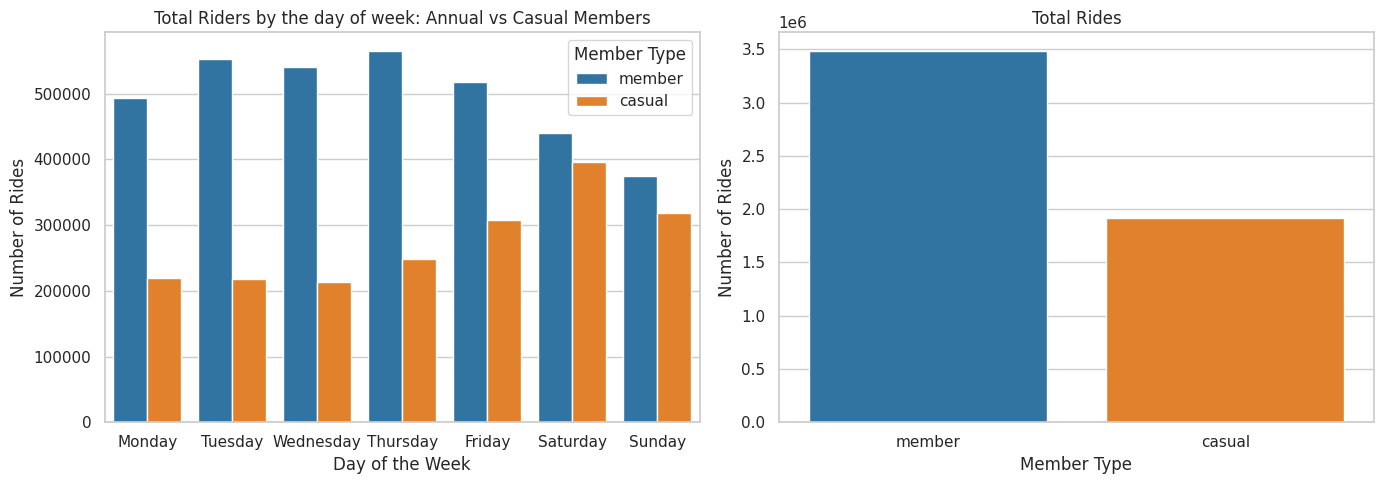

In [14]:
# Define axes that make the plot split into to charts
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Left - Total Rides by the day of the week
sns.countplot(data= clean_data,x= 'day_of_week',hue='member_casual',order=day_order,ax=axes[0],palette=custom_color)
axes[0].set_title('Total Riders by the day of week: Annual vs Casual Members')
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Number of Rides')
axes[0].legend(title='Member Type')

# Right - Total Rides
sns.countplot(data= clean_data,x='member_casual',ax=axes[1],palette = custom_color,hue='member_casual')
axes[1].set_title('Total Rides')
axes[1].set_xlabel('Member Type')
axes[1].set_ylabel('Number of Rides')

# Using tight_layout to automatic adjust spacing so label don't overlab
plt.tight_layout()
plt.show()

### 3. Viz average Riders length

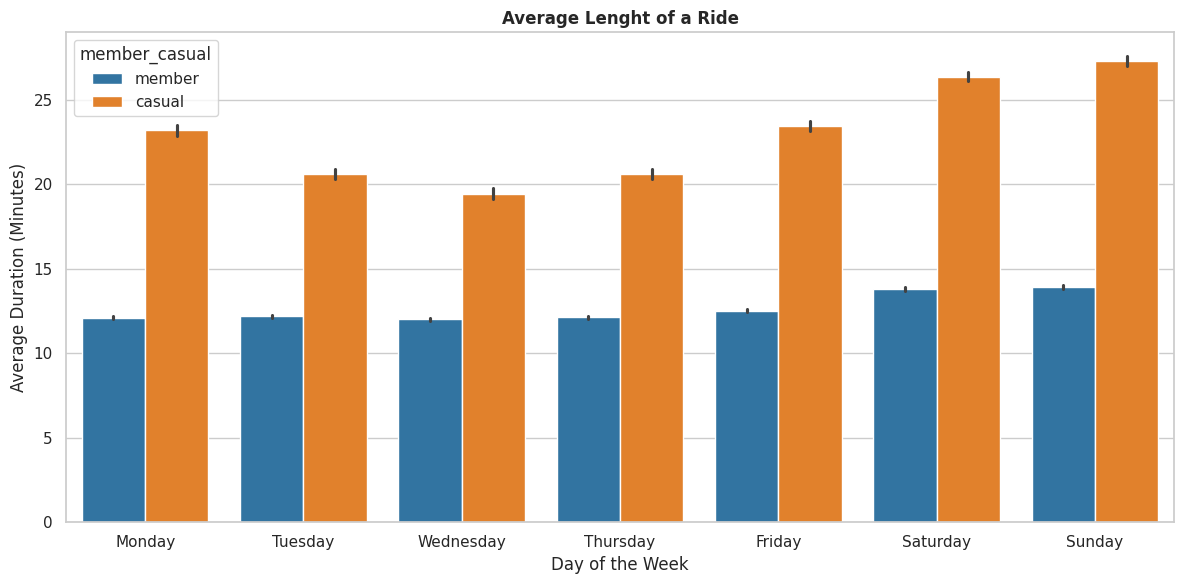

In [15]:
plt.figure(figsize=(12,6))

# Barplot use to see the mean (avgerage) of ride length
sns.barplot(
    data=clean_data,x= 'day_of_week',y= 'ride_length',hue='member_casual',
    palette=custom_color,order=day_order,estimator='mean')

# Cutomize the chart layout
plt.xlabel("Day of the Week")
plt.ylabel("Average Duration (Minutes)")
plt.title("Average Lenght of a Ride",fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Viz the Seasonality (total monthly riders)

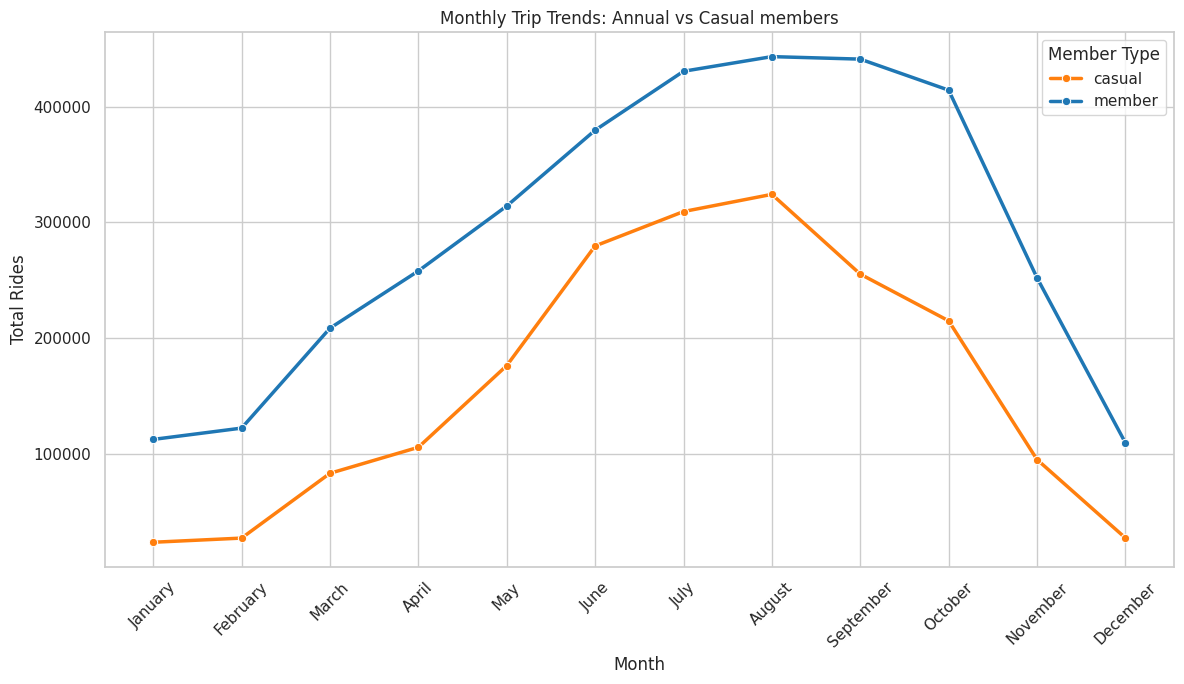

In [16]:
month_name = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

# Define a seson data from based on group between member type and month and count the total trips to use in plot
season_plot = clean_data.groupby(['member_casual','month']).size().reset_index(name='ride_count')
season_plot['month'] = pd.Categorical(season_plot['month'],categories=month_name,ordered=True)
season_plot = season_plot.sort_values(['month','member_casual'])

plt.figure(figsize=(12,7))

# Make a line plot with a marker 'o' to see every month with the total ride of it
sns.lineplot(data=season_plot,x='month',y='ride_count',hue='member_casual',
            palette = custom_color, marker = 'o', linewidth = 2.5)

plt.title('Monthly Trip Trends: Annual vs Casual members')
plt.xlabel('Month')
plt.ylabel('Total Rides')
plt.xticks(rotation=45)
plt.legend(title='Member Type')
plt.tight_layout()
plt.show()

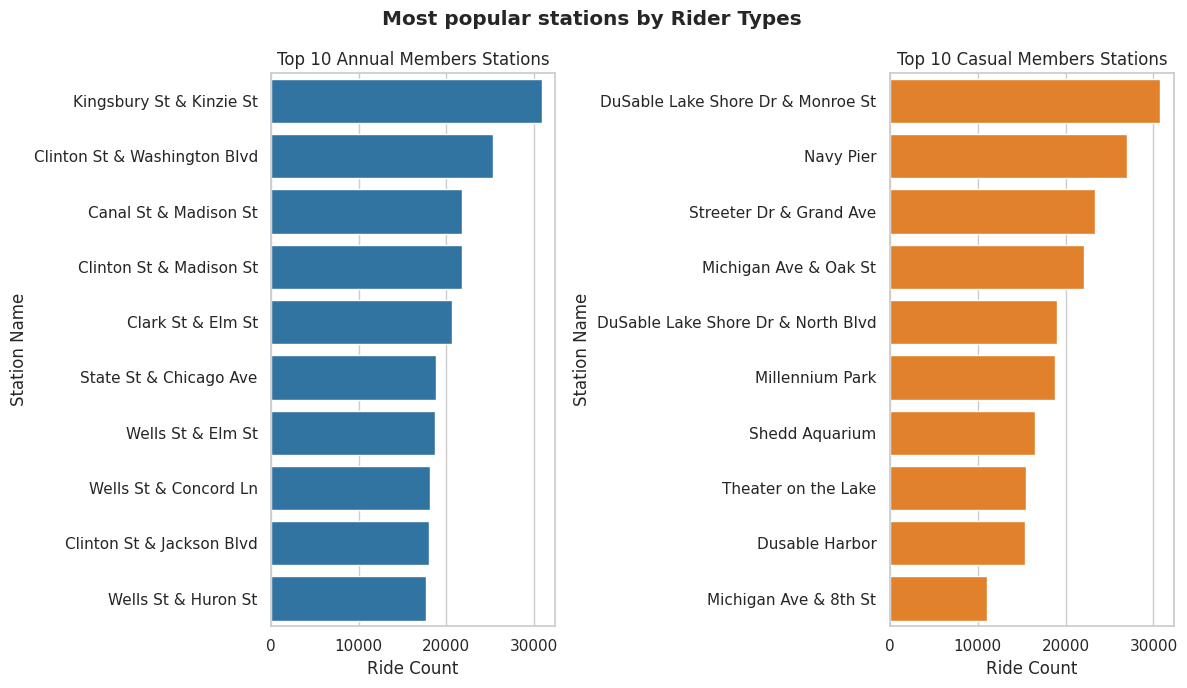

In [17]:
# Define a annual member top 10 start station locations based on the analysis number 5
top_member_location_plot = top_member_location['start_station_name'].value_counts().head(10)
top_member_location_plot = top_member_location_plot.reset_index()
top_member_location_plot.columns = ['station_name','ride_count']

# Define a casual member top 10 start station locations based on the analysis number 5
top_casual_location_plot = top_casual_location['start_station_name'].value_counts().head(10)
top_casual_location_plot = top_casual_location_plot.reset_index()
top_casual_location_plot.columns = ['station_name','ride_count']

# Make the viz to see the ride count for every member
fig,axes = plt.subplots(1,2,figsize=(12,7))

# Left - Top member location plot
sns.barplot(data=top_member_location_plot,x='ride_count',y='station_name',color='#1f77b4',ax=axes[0])
axes[0].set_title('Top 10 Annual Members Stations')
axes[0].set_ylabel('Station Name')
axes[0].set_xlabel('Ride Count')

# Right - Top member location plot
sns.barplot(data=top_casual_location_plot,x='ride_count',y='station_name',color='#ff7f0e',ax=axes[1])
axes[1].set_title('Top 10 Casual Members Stations')
axes[1].set_ylabel('Station Name')
axes[1].set_xlabel('Ride Count')

plt.suptitle('Most popular stations by Rider Types',fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Act - View The Recommendations


#### Summary of findings
* Annual Members are frequent Users with low spending time and Casual Members are high spending time with a seasonal peaks
* Annual Members are commuters ,as they follow 8 hours patterns, while Casual Members are leisure that don't follow any pattern just they show afternoon and evening peaks.
* Casual Members and Annual Members are in low Peak During Winter season. While Casual Members are harder low
* Casual Members start at tourist/leisure stations.

#### Top Recommendations
* Make a **'Weekend Membership'** for Casual users instead of annual members. This will attract them with this membership as they use the bikes mostly in weekends
* Make a **'Missing you' Campain** During the Winter season that attract many of members (Annual - Casual) to make a Ride in winter.
* Make a **'Challenges with rewards' Capmain** for members that make them more excited to use bikes. And annual members spend more time with bikes.
* Target the **Top 10 stations** with ads, Challenges point (like checkout and pop-up event) at the time they reach these stations, etc...